In [340]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [341]:
path = r"C:\Users\rawat\Downloads\data.csv"

dataframe = pd.read_csv(path,encoding_errors='ignore')


In [342]:
len(dataframe)

541909

In [343]:
# E Commerce Data 
dataframe['StockCode'] = dataframe['StockCode'].str.replace('[\\D]','',regex=True) # removing any alphabets from the stockcode 

dataframe['InvoiceDate'] = dataframe['InvoiceDate'].replace('[/]','-',regex=True) # standardizing the dateformat 

dataframe['InvoiceDate'] = pd.to_datetime(dataframe['InvoiceDate'])
pd.options.display.float_format = '{:.2f}'.format



In [344]:
# Data distribution on column Quantity based on 1,2,3 STD

dataframe['Cleaned_Quantity'] = np.cbrt(dataframe['Quantity']) # squash the distance between median and outliers  
# handles negative values does not remove or make them positive but pull that extreme value close to center 

upper_range = dataframe['Cleaned_Quantity'].quantile(0.99) # 99th quantile value = 4
lower_range = dataframe['Cleaned_Quantity'].quantile(0.01) # 0.01th quantile value = -2 

dataframe['Cleaned_Quantity'] = dataframe['Cleaned_Quantity'].clip(lower=lower_range,upper=upper_range) 
# new column created so that original data is safe for any further financial process and new data is already clipped by upper and lower range

q3 = dataframe['Cleaned_Quantity'].quantile(.75)
q2 = dataframe['Cleaned_Quantity'].quantile(.50)
q1 = dataframe['Cleaned_Quantity'].quantile(.25)

# skew = dataframe['Cleaned_Quantity'].skew()
# outliers_present = dataframe['Cleaned_Quantity'].std()/(q3-q1)  # range should be in between 0.65 to 0.74
# std = dataframe['Cleaned_Quantity'].std()
# iqr = q3-q1

# from sklearn.preprocessing import PowerTransformer
# pt = PowerTransformer('yeo-johnson',standardize=True,copy=True)
# cleaned =  pt.fit_transform(dataframe[['Cleaned_Quantity']])
# dataframe['Cleaned_Quantity'] = cleaned.flatten()
# # dataframe['Cleaned_Quantity'] = np.log1p(dataframe['Cleaned_Quantity'])
# dataframe['Cleaned_Quantity'].describe()


In [345]:
dataframe['Cleaned_Quantity'].min(),dataframe['Cleaned_Quantity'].max()

(-1.259921049894873, 4.641588833612779)

within 1 STD : 86.16%
within 2 STD : 94.22%
within 3 STD : 96.38%


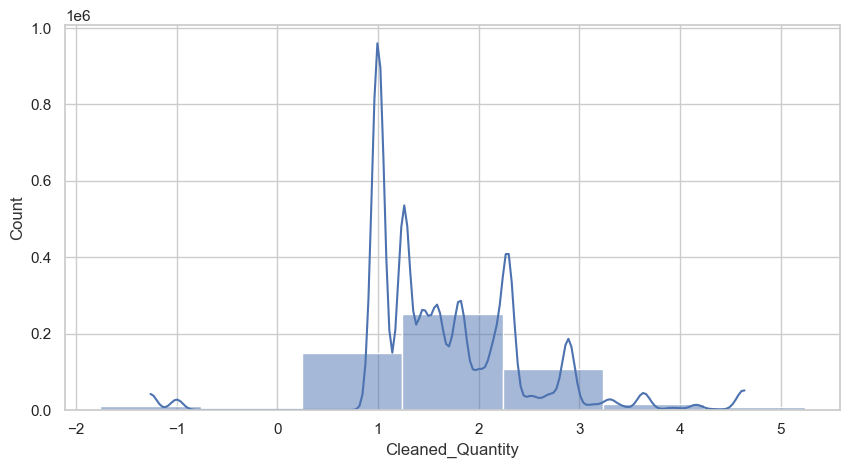

99th Percentile (Upper Boundary): 100.0
1st Percentile (Lower Boundary): -2.0
Total Outliers Found: 9995


(119769.16003068598, 2.952292607292613)

In [346]:
mean = dataframe['Cleaned_Quantity'].mean()
std = dataframe['Cleaned_Quantity'].std()

# for calculating how much of our data fits in 1st,2nd,3rd STD we do the below calculation where we get the range of our 1st 2nd 3rd STD by multiplying 1,2,3 with STD and adding or subtracting for upper or lower range
for i in [1,2,3]:
    lower = mean -(i*std)
    upper = mean +(i*std)

    withinbound = dataframe[(dataframe['Cleaned_Quantity']>=lower) & (dataframe['Cleaned_Quantity']<=upper)]
    percentage = (len(withinbound)/len(dataframe))*100

    print(f'within {i} STD : {percentage:.2f}%')

plt.figure(figsize=(10,5))
sns.histplot(dataframe['Cleaned_Quantity'],kde=True,discrete=True) 
plt.show()

# 1. Calculate the cut-off points
upper_limit = dataframe['Quantity'].quantile(0.99)
lower_limit = dataframe['Quantity'].quantile(0.01)

# 2. Flag the outliers
outliers = dataframe[(dataframe['Quantity'] > upper_limit) | (dataframe['Quantity'] < lower_limit)]

print(f"99th Percentile (Upper Boundary): {upper_limit}")
print(f"1st Percentile (Lower Boundary): {lower_limit}")
print(f"Total Outliers Found: {len(outliers)}")

# since we have quite a lot of spikes it suggests that the data is leptokurtic 
dataframe['Quantity'].kurtosis(),dataframe['Cleaned_Quantity'].kurtosis()


In [347]:
pd.options.display.float_format = '{:.2f}'.format
dataframe = round(dataframe,2)

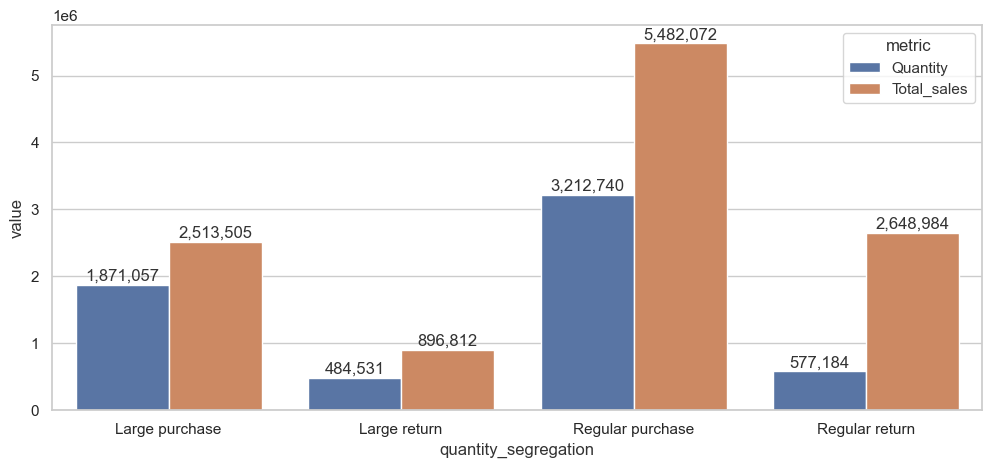

In [352]:
dataframe['zscore'] = round((dataframe['Cleaned_Quantity']-dataframe['Cleaned_Quantity'].mean())/ dataframe['Cleaned_Quantity'].std(),2)

condition = [(dataframe['zscore']<=-3),
             (dataframe['zscore']>=3),
             (dataframe['zscore']>=0)&(dataframe['zscore']<3),
             (dataframe['zscore']<0)&(dataframe['zscore']>-3)]

label = ['Large return','Large purchase',"Regular purchase",'Regular return']

dataframe['quantity_segregation'] = np.select(condlist=condition,choicelist=label)

mask = dataframe['quantity_segregation']=='Large return'

dataframe.loc[mask,'Quantity'] = dataframe.loc[mask,'Quantity'].abs()
dataframe.loc[mask,'UnitPrice'] = dataframe.loc[mask,'UnitPrice'].abs()

dataframe['Total_sales'] = round(dataframe['Quantity']*dataframe['UnitPrice'],2)

sales_figure = dataframe.groupby('quantity_segregation')[['Quantity','Total_sales']].sum().reset_index()

sales_fig = sales_figure.melt(id_vars='quantity_segregation',value_vars=['Quantity','Total_sales'],value_name='value',var_name='metric')

plt.figure(figsize=(12,5))
sns.barplot(data=sales_fig, x='quantity_segregation', y='value', hue='metric')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='{:,.0f}', padding=1)
plt.show()


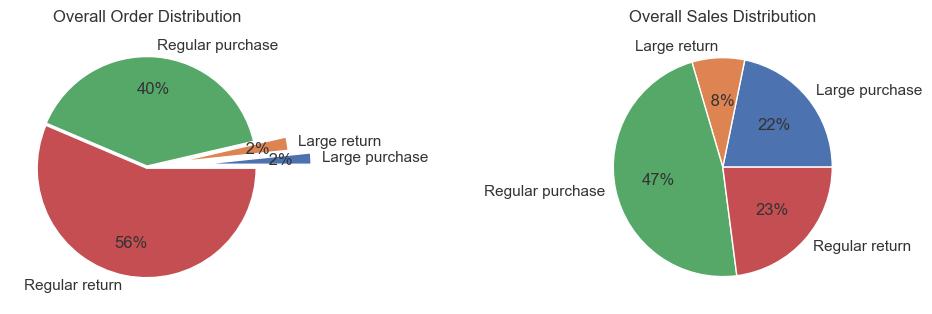

In [353]:
Profit_per = dataframe.groupby('quantity_segregation').agg(Total_orders=('InvoiceNo','count'),
                                               Total_sales =('Total_sales','sum')).reset_index()

Profit_per['Overall_orders'] = dataframe['InvoiceNo'].count()

Profit_per['Overall_sales'] = dataframe['Total_sales'].sum()

Profit_per['Order_perc'] = round(Profit_per['Total_orders']/Profit_per['Overall_orders'] * 100,2)

Profit_per['Sales_perc'] = round(Profit_per['Total_sales']/Profit_per['Overall_sales'] * 100,2)


fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax2.pie(data=Profit_per,x='Sales_perc',labels='quantity_segregation',autopct='%2.f%%')
ax2.set_title('Overall Sales Distribution')

explode = [0.5,0.3,0.01,0.01]
ax1.pie(data=Profit_per,x='Order_perc',labels='quantity_segregation',explode=explode,autopct='%2.f%%',pctdistance=0.7)
ax1.set_title('Overall Order Distribution')
plt.tight_layout(pad=3)
plt.show()



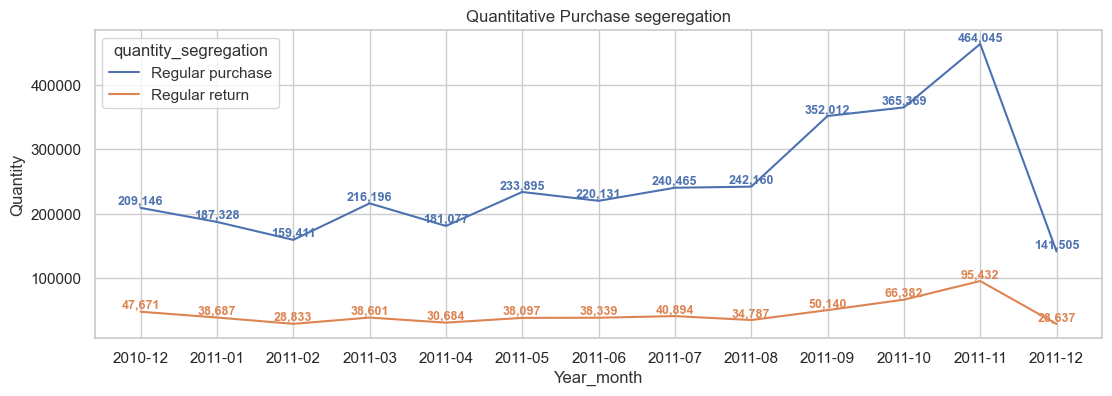

In [552]:
dataframe['Rolling_Quantity_7d'] = dataframe['Cleaned_Quantity'].rolling(window=7).mean()
dataframe['Year_month'] = dataframe['InvoiceDate'].dt.strftime('%Y-%m')

txn_type=['Regular purchase','Regular return']

quantity_over_time = dataframe[dataframe['quantity_segregation'].isin(txn_type)].groupby(['Year_month','quantity_segregation'])['Quantity'].sum().reset_index()

plt.figure(figsize=(13,4))
sns.lineplot(data=quantity_over_time,x='Year_month',y='Quantity',hue='quantity_segregation')
plt.title('Quantitative Purchase segeregation')
# plt.yscale('log')
for line in plt.gca().lines:
    # Get the exact color of the current line
    line_color = line.get_color()
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=9, color=line_color)


plt.show()

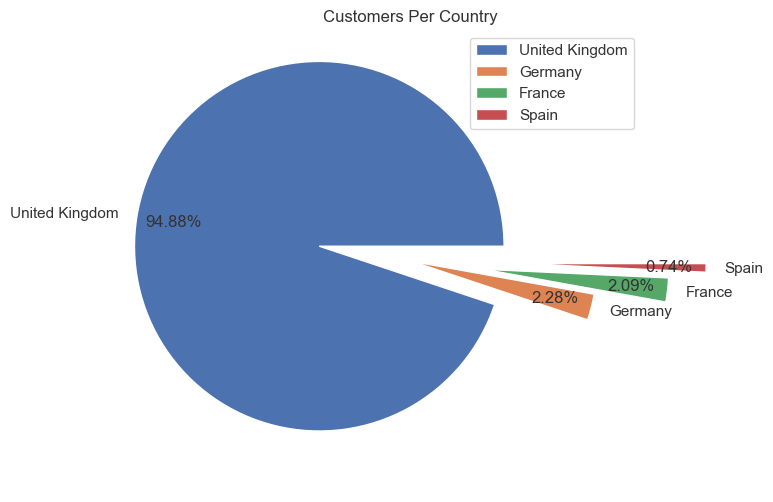

In [355]:
datafame['CustomerID'] = dataframe['CustomerID'].fillna(np.nan)

Customer_per_country = dataframe.groupby('Country')['CustomerID'].nunique().reset_index().sort_values(by='CustomerID',ascending=False).head(4)
explode = [0.5,0.01,0.4,0.6]
plt.figure(figsize=(13,6))
plt.pie(x=Customer_per_country['CustomerID'],labels=Customer_per_country['Country'],autopct='%.2f%%',pctdistance=0.8,explode=explode)
plt.title('Customers Per Country')
plt.legend()
plt.show()

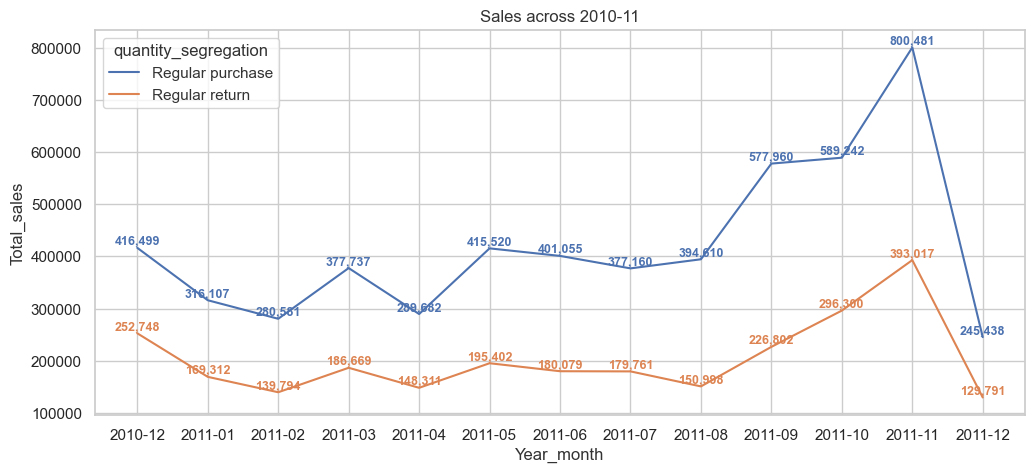

In [554]:
txn_types = ['Regular purchase','Regular return']

sales_per_year = dataframe[dataframe['quantity_segregation'].isin(txn_types)].groupby(['Year_month','quantity_segregation'])['Total_sales'].sum().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(sales_per_year,x=sales_per_year['Year_month'],y=sales_per_year['Total_sales'],color='#79AE6F',hue=sales_per_year['quantity_segregation'])
plt.ylabel('Total_sales')
plt.title('Sales across 2010-11')
for line in plt.gca().lines:
    # Get the exact color of the current line
    line_color = line.get_color()
    
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=9, color=line_color)
plt.show()


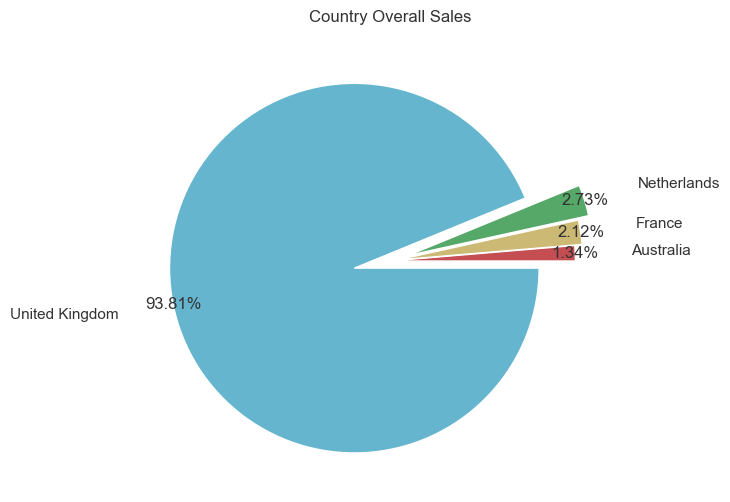

In [357]:
countries = ['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA']
# countries to choose from above 

sales = dataframe[(dataframe['Country'].isin(countries[:4])) & (dataframe['quantity_segregation']!='High Return')]

sales_per_country = sales.groupby(['Country'])['Total_sales'].sum().reset_index()

plt.figure(figsize=(10,6))
explode = [0,.04,0.1,0.2]
plt.pie(x=sales_per_country['Total_sales'],pctdistance=True,autopct='%.2f%%',colors='rygc',explode=explode,labels=sales_per_country['Country'],labeldistance=1.3)
plt.title('Country Overall Sales')
plt.show()


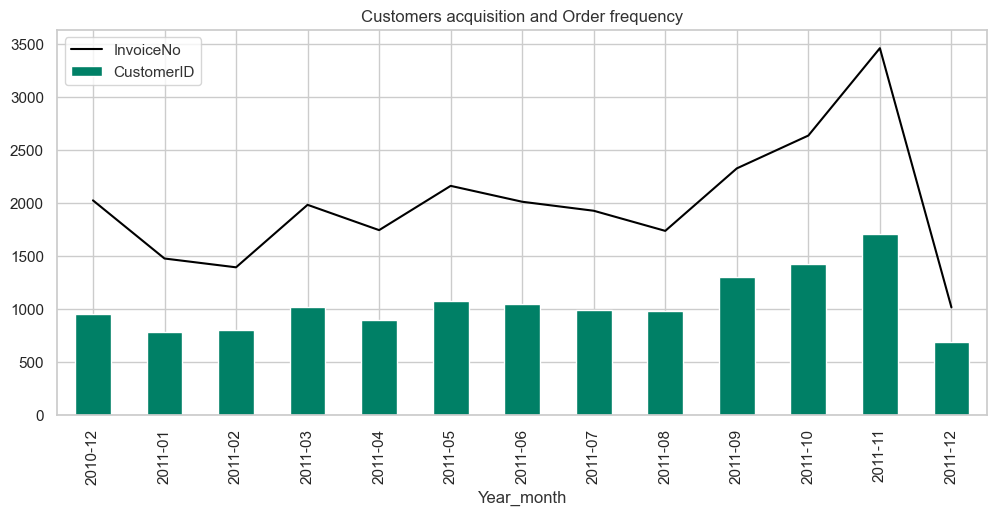

In [ ]:
# Order Frequency per month 

Orders_per_month = dataframe.groupby('Year_month')['InvoiceNo'].nunique()
customers_per_month = dataframe.groupby('Year_month')['CustomerID'].nunique()

plt.figure(figsize=(12,5))
Orders_per_month.plot(kind='line',colormap='bone')
customers_per_month.plot(kind='bar',colormap='summer')
plt.title('Customers acquisition and Order frequency')
plt.legend()
plt.show()



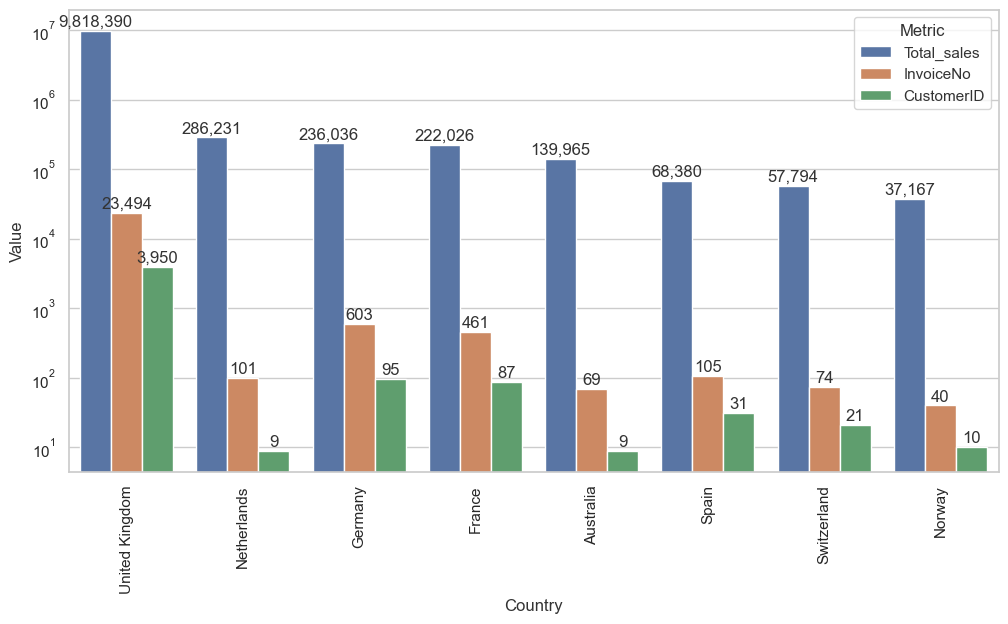

In [ ]:
import numpy as np
import plotly.express as px

# this is for a single country
class country: 
    def __init__(self,country):
        self.country = country 

    def info(self):
         
    
class compare_countries: # this is specifically for comparing multiple countries 
        def __init__(self,countries=None):
             self.countries = countries
        
        def compare(self):
            data = dataframe[dataframe['Country'].isin(self.countries)]
            pivot_table = data.pivot_table(index='Country',values=['Total_sales','InvoiceNo','CustomerID'],
                                       aggfunc={'Total_sales':'sum','InvoiceNo':'nunique','CustomerID':'nunique'}).reset_index().sort_values(by='Total_sales',ascending=False)

            return pivot_table
        
        def charts(self):
            data = dataframe[(dataframe['Country'].isin(self.countries)) & (dataframe['quantity_segregation']!='High Return')]
            pivot_table = data.pivot_table(index='Country',values=['Total_sales','InvoiceNo','CustomerID'],
                                       aggfunc={'Total_sales':'sum','InvoiceNo':'nunique','CustomerID':'nunique'}).reset_index().sort_values(by='Total_sales',ascending=False)


            df_melted = pivot_table.reset_index().melt(id_vars='Country', 
                                          value_vars=['Total_sales', 'InvoiceNo', 'CustomerID'],
                                          var_name='Metric', 
                                          value_name='Value')

            plt.figure(figsize=(12, 6))
            sns.barplot(data=df_melted, x='Country', y='Value', hue='Metric')
            plt.xticks(rotation=90)
            plt.yscale('log'),
            for container in plt.gca().containers:
                 plt.gca().bar_label(container,fmt='{:,.0f}',padding=1)
            plt.show()

          
        
compare = compare_countries(countries[:8])

compare.compare()
compare.charts()



In [537]:
dataframe.Description.unique().tolist()

def category(text):
    text = str(text).lower()

    if any(word in text for word in ['t-light holder','bulb','lantern']):
        return 'Electronics'
    if any(word in text for word in ['rack','cabinet','picture frame','frame','doorsign','enamel','doormat','block word','alarm clock','clock','tissues']):
        return 'Household'
    if any(word in text for word in ['game','games','toy','playhouse','jigsaw blocks','alphabet blocks','lunch box','puzzles','jigsaw','lunchbag','doll','snakes & ladder','dominoes']):
        return 'Childrens'
    if any(word in text for word in ['cutlery','coaster','jam','saucer','mug','cup','plate','crocekry','bottle','teaspoons',' tea ','spoons']):
        return 'Kitchen appliances'
    if any(word in text for word in ['hand warmer','postage','paint set','paint','sewing','jumbo bag']):
        return 'Essentials'
    if any(word in text for word in ['cases','tape']):
        return 'Packging'
    return "Other"

dataframe['Category'] = dataframe['Description'].apply(category)

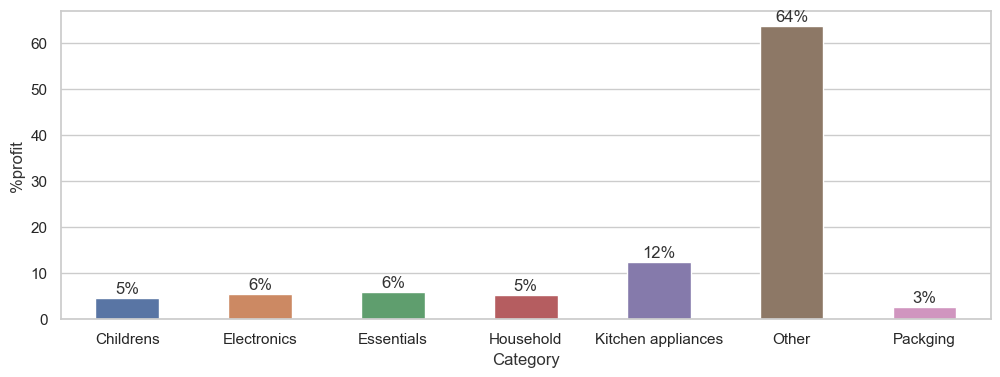

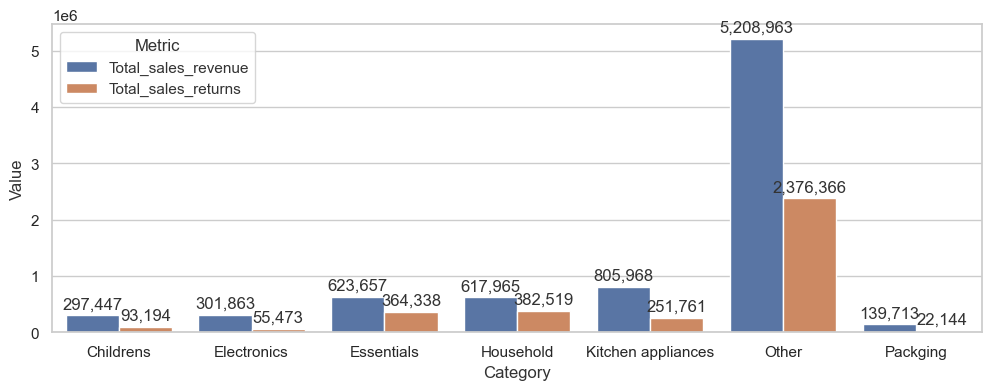

In [538]:
txn_type = ['Large return','Regular return']
txn_type2= ['Large purchase','Regular purchase']

total_returns = dataframe[dataframe['quantity_segregation'].isin(txn_type)].groupby('Category')['Total_sales'].sum().reset_index()
total_revenue = dataframe[dataframe['quantity_segregation'].isin(txn_type2)].groupby('Category')['Total_sales'].sum().reset_index()

total_profit = pd.merge(left=total_returns,right=total_revenue,on='Category',how='inner',suffixes=['_returns','_revenue'])

total_profit['profit'] = round(total_profit['Total_sales_revenue']-total_profit['Total_sales_returns'],2)

total_profit['overall_profit'] = total_profit['profit'].sum()

total_profit['%profit'] = round(total_profit['profit']/total_profit['overall_profit']*100,2)

plt.figure(figsize=(12,4))
sns.barplot(data=total_profit,x='Category',y='%profit',hue='Category',gap=0.4)
for container in plt.gca().containers:
    plt.gca().bar_label(container,fmt='{:,.0f}%',padding=1)
plt.show()

melted_table = total_profit.melt(id_vars='Category',
                  value_vars=['Total_sales_revenue','Total_sales_returns'],
                  var_name='Metric',
                  value_name='Value')

plt.figure(figsize=(12,4))
sns.barplot(data=melted_table,x='Category',y='Value',hue='Metric')
for container in plt.gca().containers:
    plt.gca().bar_label(container,fmt='{:,.0f}',padding=3,label_type='edge',)
plt.show()

In [547]:
a = [1,2,3,4,5,6]
b = ['a','x','b','c','f','g']

list(zip(a,b))

[(1, 'a'), (2, 'x'), (3, 'b'), (4, 'c'), (5, 'f'), (6, 'g')]